# Instalando as Bibliotecas Necessárias



In [1]:
# Installing the numpy, netcdf4, boto3 and gdal libraries
!pip install -q cartopy boto3 gdal salem rasterio pyproj geopandas descartes

# download do arquivo "utilities_goes16e19.py"
!wget -c https://github.com/evmpython/Minicurso_UFCG_nov_2025/raw/main/utils/utilities_goes16e19.py

# download da paleta de cores para o canal do infravermelho
!wget -c https://github.com/evmpython/Minicurso_UFCG_nov_2025/raw/main/utils/ir.cpt

# Monta drive
from google.colab import drive
drive.mount('/content/drive')

# Caminho do diretório
dir = '/content/drive/MyDrive/PYHTON/00_GITHUB/4_SATELITE/codigos_imagem_satelite_REFERENCIA'

# Diretório de Saída
import os
dir_output = f'{dir}/output/SAT_03'
os.makedirs(dir_output, exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 99.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 97.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.1 MB/s eta 0:00:00
--2026-01-27 19:14:14--  https://github.com/evmpython/Minicurso_UFCG_nov_2025/raw/main/utils/utilities_goes16e19.py
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/evmpython/Minicurso_UFCG_nov_2025/main/utils/utilities_goes16e19.py [following]
--2026-01-27 19:14:14--  https://ra

# Projeção Retangular em Níveis de Cinza

Remapping...
Remap finished! Time: 0.11 seconds


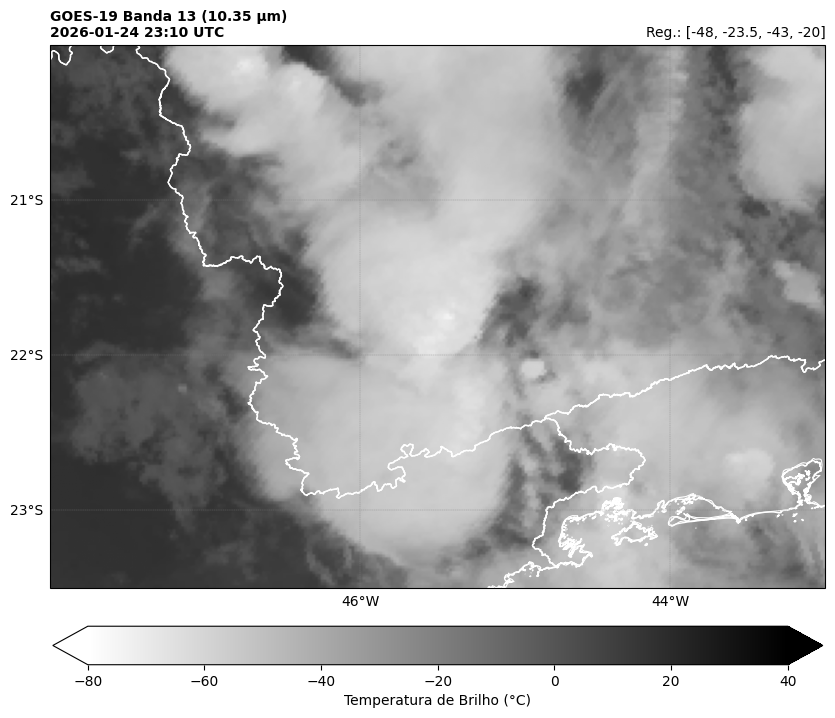

In [2]:
#========================================================================================================================#
#                                          IMPORTAÇÃO DAS BIBLIOTECAS
#========================================================================================================================#
import xarray as xr
import matplotlib.pyplot as plt
import cartopy, cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
from datetime import datetime
from utilities_goes16e19 import download_CMI, remap
import numpy as np
import os

#========================================================================================================================#
#                                        CRIA DIRETÓRIO DE ENTRADA E SAÍDA
#========================================================================================================================#
input = "/content/input"; os.makedirs(input, exist_ok=True)
output = dir_output

#========================================================================================================================#
#                                               DOWNLOAD DO ARQUIVO
#========================================================================================================================#
# data de processamento
yyyymmddhhmn = '202601242310'

# define o satélite: GOES-16 ou GOES-19
start_g19 = datetime(2025,4,7,0,0)
imagem_atual = datetime.strptime(yyyymmddhhmn, '%Y%m%d%H%M')
goes_number = '16' if imagem_atual < start_g19 else '19'

# canal do ABI
band = '13'

# download do arquivo (CMI: "Cloud and Moisture Imagery" Product)
file_name = download_CMI(yyyymmddhhmn, band, goes_number, input)

# caminho do arquivo que foi baixado
path = f'{input}/{file_name}.nc'

#========================================================================================================================#
#                                         REPROJETA E FAZ A LEITURA DO ARQUIVO
#========================================================================================================================#
# limites
lonmin, lonmax, latmin, latmax = -48, -43, -23.5, -20

# área desejada (min lon, min lat, max lon, max lat)
extent = [lonmin, latmin, lonmax, latmax]

# chama a função que faz a reprojeção (file, variable, extent, resolution)
grid = remap(path, 'CMI', extent, 2)

# leitura do dado e transforma para °C
data = grid.ReadAsArray() - 273.15

#========================================================================================================================#
#                                                 PLOT THE IMAGE
#========================================================================================================================#
# tamanho da figura (largura x altura em polegadas)
plt.figure(figsize=(10,10))

# projeção geoestacionária do cartopy
ax = plt.axes(projection=ccrs.PlateCarree())

# define a extensão da imagem
img_extent = [extent[0], extent[2], extent[1], extent[3]] # Min lon, Max lon, Min lat, Max lat

# escala de cores
colormap = "gray_r" # escala de cores na ordem reversa - branco para preto para o canal do IR

# plota imagem
img = ax.imshow(data, origin='upper', vmin=-80, vmax=40, extent=img_extent, cmap=colormap)

# linhas costeiras, bordas e linhas de grade do mapa
ax.coastlines(resolution='10m', color='white', linewidth=0.8)
ax.add_feature(cartopy.feature.BORDERS, edgecolor='white', linewidth=0.5)
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='gray', alpha=1.0, linestyle='--', linewidth=0.25, xlocs=np.arange(-180, 180, 2), ylocs=np.arange(-90, 90, 1), draw_labels=True)
gl.top_labels = False
gl.right_labels = False

# plota estados
shapefile = list(shpreader.Reader('https://github.com/evmpython/Minicurso_UFCG_nov_2025/raw/main/utils/BR_UF_2019.shp').geometries())
ax.add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='white', facecolor='none', linewidth=1.0)

# barra de cores
plt.colorbar(img, label='Temperatura de Brilho (°C)', extend='both', orientation='horizontal', pad=0.05, fraction=0.05)

# leitura da data/horário do arquivo NetCDF como uma string
date = (datetime.strptime(xr.open_dataset(path).time_coverage_start, '%Y-%m-%dT%H:%M:%S.%fZ')).strftime('%Y-%m-%d %H:%M UTC')

# título da figura
plt.title(f'GOES-{goes_number} Banda {band} (10.35 µm)\n{date}', fontweight='bold', fontsize=10, loc='left')
plt.title('Reg.: ' + str(extent) , fontsize=10, loc='right')

# salva figura
plt.savefig(f'{output}/SAT_03_G{goes_number}_ch{band}_retangular_cinza_{date.replace(" ", "_")}.jpg', bbox_inches='tight', dpi=300)

# mostra figura na tela
plt.show()